In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from graphviz import Digraph

# TODO: Can we also apply BFS here? Is it related to backprop
def trace(root):
    """ Builds a set of all nodes and edges in a graph by applying depth-first search (DFS)"""
    nodes, edges = set(), set()
    
    def dfs(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._children:
                edges.add((child, v)) # Is it directed?
                dfs(child)
    
    dfs(root)
    return nodes, edges
    

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR: left to right

    def make_node_id(node, op=''):
        return str(id(node)) + op

    nodes, edges = trace(root)
    for v in nodes:
        uid = make_node_id(v)
        # For any value in the graph, create a rectangular (record) node for it
        dot.node(name=uid, label="{%s | data=%.4f | grad=%.4f}" % (v.label, v.data, v.grad), shape='record')
        if v._op:
            # If this value is a result of some operation, create an op node and connect it
            uid_op = make_node_id(v, v._op)
            dot.node(name=uid_op, label=v._op)
            dot.edge(uid_op, uid)
    
    for u, v in edges:
        # Connect nides with operations
        dot.edge(make_node_id(u), make_node_id(v, v._op))

    return dot


In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._children = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data,  (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')        

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self, ), f"**{other}")

        def _backward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        # tanh = e**(2x) - 1 / e**(2x) + 1
        e = math.exp(2*self.data)
        t = (e - 1) / (e + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            # derivative of tanh is 1 - tanh(n)**2
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            # Build topological sort using DFS post-order traversal
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        
        # Make the topological order from root to leaf nodes    
        build_topo(self)
        # Set the base case
        self.grad = 1.0       
        # Call backward
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self 
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __truediv__(self, other): # self / other
        return self * other**-1

    def __radd__(self, other): # other + self
        return self + other

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"


In [41]:
a = Value(3.0)
b = Value(2.0)
print(2 * a) # 2.__mul__(a) doesn't work and Python tries the reverse order a.__rmul__()
print(a / b)
print(a - b)

Value(data=6.0, label=)
Value(data=1.5, label=)
Value(data=1.0, label=)


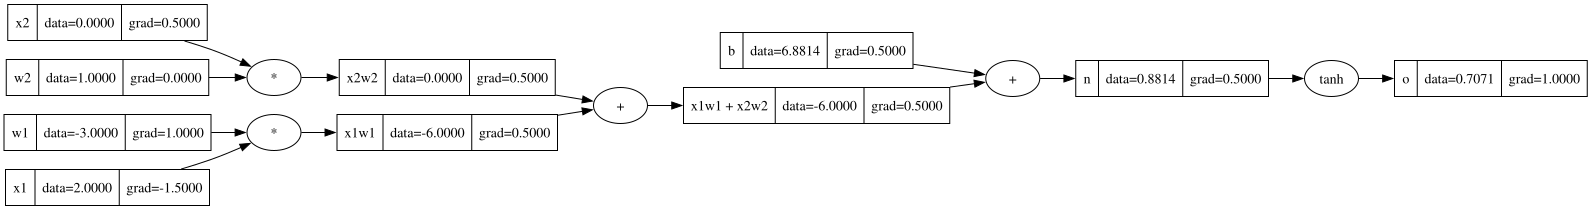

In [42]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')

# network
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

draw_dot(o)

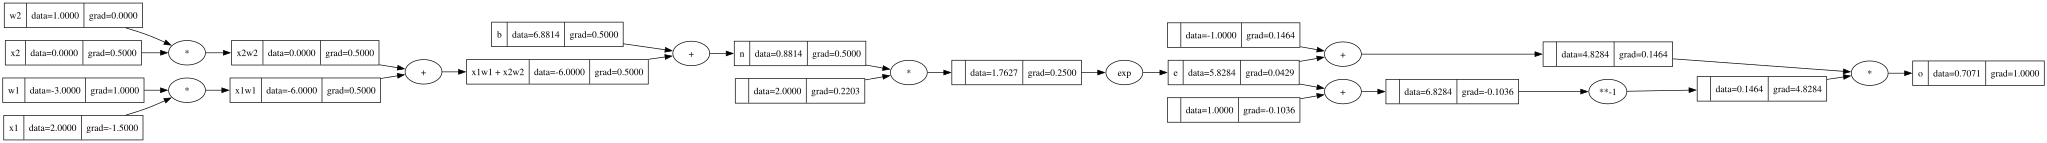

In [37]:
# Now let's write tanh explicitly

# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')

# network
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'

# NOTE: tanh = e**(2x) - 1 / e**(2x) + 1
e = (2 * n).exp(); e.label = 'e'
o = (e - 1) / (e + 1) ; o.label = 'o'

o.backward()
draw_dot(o)

In [45]:
# Doing the same thing with PyTorch
import torch

# In PyTorch we have Tensor objects, instead of our Value objects
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
o.backward()

# Hopefully we will get the same results
print(o.data.item())
print('---')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())

0.7071066904050358
---
x1 -1.5000003851533106
w1 1.0000002567688737
x2 0.5000001283844369
w2 0.0
